# Notebook 37 — prior provenance, boundary mechanism, and claim ledger

**Plan of record:** `docs/NOTEBOOK_37_CLAUDE_PLAN.md`  ·  **Module:** `sleep_sbi.figure10_notebook37_claude`

This notebook answers two questions and refuses to conflate them.

| | Question | Status going in |
|---|---|---|
| **Q1** | What *is* the Figure-10 prior box, per parameter, and what may the dissertation claim from it? | Largely settled on disk — confirm and hash, do not re-litigate |
| **Q2** | Is the box's construction a contributing cause of the Notebook 35/36 coverage failure? | Genuinely open, testable at **zero new simulation** |

Notebook 36 concluded `MIXING_ITSELF_IS_THE_DEFECT_NOT_THE_WEIGHTS`. That is a statement about
*aggregation*. It does not exclude a second, prior-side mechanism, and nobody has tested one. If Q2
comes back positive, Notebook 38's single bounded repair should be **prior re-anchoring**, not
**re-aggregation** — so this notebook changes what NB38 does.

**Hard locks.** No training. No simulation. Sealed bank is metadata-only. The module imports
`numpy/pandas/scipy/statsmodels` and nothing else — it is structurally incapable of training, and
`test_notebook37_claude.py` asserts that.

In [1]:
import importlib.util
import json, sys
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "S4_sbi").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
MODULE_PATH = PROJECT_ROOT / "S4_sbi" / "src" / "sleep_sbi" / "figure10_notebook37_claude.py"

# Loaded by path rather than through `sleep_sbi.__init__`, which pulls in the observation
# stack (mne, torch).  NB37 must stay import-light: that is what makes "no training" a
# structural property rather than a promise.
_spec = importlib.util.spec_from_file_location("figure10_notebook37_claude", MODULE_PATH)
nb37 = importlib.util.module_from_spec(_spec)
sys.modules[_spec.name] = nb37  # required before exec_module: @dataclass resolves via sys.modules
_spec.loader.exec_module(nb37)

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 70)

paths = nb37.artifact_paths()
print("artifact root :", paths["root"].relative_to(PROJECT_ROOT))
print("torch loaded  :", "torch" in sys.modules, "| sbi loaded:", "sbi" in sys.modules)
print("schema        :", nb37.SCHEMA_VERSION)

artifact root : S4_sbi\results\figure10_8d_7d\artifacts\notebook_37_claude
torch loaded  : False | sbi loaded: False
schema        : nb37-claude-v1


## Phase 0 — pre-registration, then inputs

The protocol lock is written **before** any statistic is computed. It contains rules, never
outcomes: the coverage definition, the boundary-proximity definition, the three tests with their
predicted signs, the interior/boundary split rule (computed from `theta_true_unit` alone, so it
cannot see a result), the exclusion policy, and the mapping from verdict to NB38 repair ordering.

One design choice matters and is recorded up front: the primary estimator for the mechanism test is
**`member_1`, not the ensemble**. Notebook 36 proved the equal-weight mixture is itself defective, so
testing on a single member is what separates a prior-side mechanism from the known aggregation defect.

In [2]:
lock_path, protocol_sha = nb37.write_protocol_lock()
lock = nb37.protocol_lock()

print("protocol_lock.json sha256:", protocol_sha)
print()
for test_id, spec in lock["tests"].items():
    print(f"{test_id}  role={spec['role']}")
    print(f"      {spec['statistic']}")
    if "predicted_sign" in spec:
        print(f"      predicted: {spec['predicted_sign']}")
print()
print("interior/boundary split :", lock["tests"]["T_C"]["split_rule"])
print("primary estimator       :", nb37.PRIMARY_ESTIMATOR)

protocol_lock.json sha256: acbfa9cbc1ee3a750bca53e086e5607169f99d090fb887119da970c7acce3894

T_A  role=corroboration_only
      Spearman rho between per-parameter contraction ratio and boundary-minus-interior coverage delta
      predicted: positive
T_B  role=primary
      logistic regression: covered ~ boundary_proximity + C(parameter)
      predicted: negative coefficient on boundary_proximity
T_C  role=discriminating
      joint-rank KS vs uniform, interior quartile vs boundary quartile

interior/boundary split : p_case quartiles; interior = bottom 25%, boundary = top 25%; computed from theta_true_unit alone, before any rank is inspected
primary estimator       : member_1


In [3]:
manifest = nb37.build_input_manifest()
(paths["json"] / "input_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")

print(f"declared inputs: {manifest['n_declared']}   missing: {manifest['n_missing']}")
if manifest["missing"]:
    print("MISSING:", manifest["missing"])
pd.DataFrame(manifest["inputs"]).assign(
    sha256=lambda d: d["sha256"].str[:12]
)[["name", "exists", "sha256", "bytes"]].head(12)

declared inputs: 27   missing: 0


,name,exists,sha256,bytes
0,fig10_config,True,a4eb07b24f84,18230
1,route3_7d_config,True,2cedb6a68de3,8562
2,v8a_source,True,9e4f525bee28,71033
3,v7_source,True,ae7881c0df25,69281
4,freeze_search_source,True,c20987e072f2,16141
5,freeze_best_json,True,bf18212ebac0,877
6,eeg_route_decision,True,930deb204439,1111
7,forward_model_decision,True,1f7a78e85a1b,1320
8,c_ctx2th_dossier,True,b4bc0e5fa34c,7757
9,n35_auth_a_gate,True,751afdb0df99,768


### Sealed-bank guard

The guard is exercised, not merely declared: reading the sealed *provenance JSON* is allowed and
returns allowlisted keys only; reading any case-level array under `sealed_confirm_512` raises.

In [4]:
meta = nb37.read_sealed_metadata(
    nb37.SEALED_ROOT / "sealed_confirm_512" / "sealed_provenance.json"
)
print("allowed metadata :", {k: v for k, v in meta.items() if k != "_dropped_keys_outside_allowlist"})
print("dropped keys     :", meta["_dropped_keys_outside_allowlist"])

try:
    nb37.assert_not_sealed_case_data(
        nb37.SEALED_ROOT / "sealed_confirm_512" / "8d" / "shard_0000000_0000512.npz"
    )
    print("\nGUARD FAILED — case-level read was permitted")
except nb37.SealedAccessViolation as exc:
    print("\nguard OK:", exc)

allowed metadata : {'bank_id': 'sealed_confirm_512', 'created_utc': '2026-08-06T05:18:58.147880+00:00', 'cases_per_track': 512, 'seed_disjointness': {'n36_seeds': {'bootstrap': 9639001, 'permutation_test': 9638001, 'sealed_posterior_sampling_7d': 9633001, 'sealed_posterior_sampling_8d': 9632001, 'sealed_simulator_base': 9631001, 'sealed_sobol': 9630001, 'support_safe_global_7d': 9637001, 'support_safe_global_8d': 9636001, 'support_safe_lc2st_7d': 9635001, 'support_safe_lc2st_8d': 9634001}, 'protocol_seed_count': 35, 'n35_reserved_seeds': [9355001, 9610001, 9611001], 'collisions': [], 'disjoint': True}, 'shard_sha256': {'8d': {'shard_0000000_0000064.npz': '659209ab86e4c23b0d2952682e58b75665825a48f805666351a1dbd90eb6eb2f', 'shard_0000064_0000128.npz': '7878a87e3dd3e73b7870d719be630587d077c1a84cd631ce8242a0fb8f920360', 'shard_0000128_0000192.npz': 'cd3cbf16ecb2dd9dc66f08ae1b36c789384f2206845a79eed58485f8fbc3bf81', 'shard_0000192_0000256.npz': '75b7f2db87c4090a3297930e6664c64fd30830f2912d0

## Phase A — settled facts (confirm-and-hash)

Seven facts, one cell. No gate machinery, no suspense: each is an assertion against a file that
already exists. Spending a decision gate on a question the disk has already answered is how an audit
starts manufacturing drama.

In [5]:
facts = nb37.settled_facts()
facts_df = pd.DataFrame([f.to_row() for f in facts])
facts_df.to_csv(paths["csv"] / "settled_facts.csv", index=False)

for f in facts:
    mark = "OK  " if f.holds else "FAIL"
    print(f"[{mark}] {f.fact_id}  {f.statement}")
print()
print("all facts hold:", all(f.holds for f in facts))

[OK  ] S1  A real-EEG posterior is unreachable: the shared EEG/rate schema was rejected and the forward-model route is NO-GO.
[OK  ] S2  The training observable is a 14D cortical-rate summary explicitly flagged not_eeg.
[OK  ] S3  The frozen config labels the prior an independent uniform box while the source defines part of it as a multiplicative envelope around an SC4001-fitted point.
[OK  ] S4  c_ctx2th is carried by zero of the 14 observables and does not contract.
[OK  ] S5  An independent real-EEG run reached the same unidentifiability conclusion for c_ctx2th (multimodal marginal, CI spanning nearly the whole prior, SBC passing).
[OK  ] S6  The estimator is not calibrated: joint coverage, SBC, and L-C2ST all fail.
[OK  ] S7  The sealed confirmation bank was generated but never opened or consumed.

all facts hold: True


In [6]:
route = nb37.derive_claim_route(facts)
print("claim route :", route["claim_route"])
print("allowed     :", route["allowed_claim"])
print()
for blocker in route["route_a_blockers"]:
    print("  Route A blocked by:", blocker)

claim route : B
allowed     : DE provides a subject-specific candidate digital twin from real EEG; SBI provides synthetic-domain identifiability and uncertainty diagnostics for the simulator parameterization

  Route A blocked by: route_1_shared_schema_go=false (EEG/rate schema parity rejected)
  Route A blocked by: route_2 forward model NO-GO (no validated measurement map)
  Route A blocked by: training observable declares not_eeg=true


## Phase B — prior-bound provenance, parsed from source

The bounds are extracted from `models/s4_personalize_fig7_v8.py` with `ast`, so the **construction
rule** is captured verbatim rather than reduced to two numbers. That is what makes the provenance
claim auditable: `(_V4_BEST["mue"] * 0.85, _V4_BEST["mue"] * 1.15)` is evidence in a way that
`(3.31075, 4.47925)` is not.

In [7]:
provenance = nb37.prior_bound_provenance()
provenance.to_csv(paths["csv"] / "prior_bound_provenance.csv", index=False)

provenance[[
    "parameter", "lower", "upper", "construction_rule", "anchored_on",
    "v4_best_value", "v4_best_inside_box", "subject_specific", "matches_frozen_config",
]]

,parameter,lower,upper,construction_rule,anchored_on,v4_best_value,v4_best_inside_box,subject_specific,matches_frozen_config
0,mue,3.31075,4.47925,"(_V4_BEST[""mue""] * 0.85, _V4_BEST[""mue""] * 1.15)",_V4_BEST,3.8950,True,True,True
1,mui,2.57295,3.48105,"(_V4_BEST[""mui""] * 0.85, _V4_BEST[""mui""] * 1.15)",_V4_BEST,3.0270,True,True,True
2,b,28.40000,42.60000,"(_V4_BEST[""b""] * 0.80, _V4_BEST[""b""] * 1.20)",_V4_BEST,35.5000,True,True,True
3,tauA,998.20000,1853.80000,"(_V4_BEST[""tauA""] * 0.70, _V4_BEST[""tauA""] * 1.30)",_V4_BEST,1426.0000,True,True,True
4,g_LK,0.02000,0.07000,"(0.020, 0.070)",literal,0.0564,True,False,True
5,g_h,0.03500,0.09500,"(0.035, 0.095)",literal,0.0517,True,False,True
6,c_th2ctx,0.00000,0.07500,"(0.00, 0.075)",literal,0.0986,False,False,True
7,c_ctx2th,0.05000,0.22000,"(0.05, 0.22)",literal,0.0380,False,False,True


In [8]:
n_sub = int(provenance["subject_specific"].sum())
n_out = int((~provenance["v4_best_inside_box"].astype(bool)).sum())
cfg_prior_type = json.loads(nb37.FIG10_CONFIG.read_text(encoding="utf-8"))[
    "contracts"]["primary_8d"]["prior_type"]

print(f'frozen config declares prior_type = "{cfg_prior_type}"')
print(f"source shows {n_sub}/{len(provenance)} bounds are _V4_BEST multiplicative envelopes")
print(f"and {n_out}/{len(provenance)} boxes EXCLUDE the fitted value:")
for row in provenance[~provenance["v4_best_inside_box"].astype(bool)].itertuples():
    print(f"    {row.parameter:9s} V4 best = {row.v4_best_value:<8.4g} box = [{row.lower:g}, {row.upper:g}]")
print()
print("=> neither 'independent of the subject' nor 'nested on the subject' is true of the whole box.")
print("   Only a per-parameter statement is defensible.")

frozen config declares prior_type = "independent uniform box"
source shows 4/8 bounds are _V4_BEST multiplicative envelopes
and 2/8 boxes EXCLUDE the fitted value:
    c_th2ctx  V4 best = 0.0986   box = [0, 0.075]
    c_ctx2th  V4 best = 0.038    box = [0.05, 0.22]

=> neither 'independent of the subject' nor 'nested on the subject' is true of the whole box.
   Only a per-parameter statement is defensible.


### The 7D frozen value, audited against the script that produced it

`c_ctx2th = 0.1253491302153237` is described in the frozen config as the *"Notebook 10 canonical V8a
local best"*. The audit checks that description against the producing script.

In [9]:
freeze = nb37.freeze_audit()
(paths["json"] / "freeze_audit.json").write_text(json.dumps(freeze, indent=2), encoding="utf-8")

for key in ["frozen_value", "matches_best_so_far", "source_sha256_declared",
            "source_sha256_observed", "producing_script", "objective_used",
            "objective_is_v8a_fitness", "local_search_box", "winning_point_feasible",
            "winning_point_n_passed", "winning_point_failed_constraints",
            "inside_8d_prior_box", "inside_sweep_pac_hotspot_0155_0200"]:
    print(f"{key:38s} {freeze[key]}")
print()
print("caveats that must travel with any 7D result:")
for c in freeze["caveats"]:
    print("  -", c)

frozen_value                           0.1253491302153237
matches_best_so_far                    True
source_sha256_declared                 bf18212ebac0ebec39d4f13aecd5b7a9da5618ffe78abb5f8694a67f569af76a
source_sha256_observed                 bf18212ebac0ebec39d4f13aecd5b7a9da5618ffe78abb5f8694a67f569af76a
producing_script                       valid_scripts/local_search_v8a_ultra_narrow_t6_t13.py
objective_used                         diagnostic_score
objective_is_v8a_fitness               False
local_search_box                       [0.105, 0.135]
winning_point_feasible                 False
winning_point_n_passed                 12
winning_point_failed_constraints       T6
inside_8d_prior_box                    True
inside_sweep_pac_hotspot_0155_0200     False

caveats that must travel with any 7D result:
  - selected by an objective that is not the V8a fitness
  - winning point is not feasible under T1-T13 (fails T6)
  - single point, single DE seed, single subject (SC4001)
  - l

### The leakage channel, named rather than tabulated

DE and SBI do not share an observation space. DE scores `shape_r` against the real SC4001 Welch PSD
plus T1–T13 constraints on simulated rates; SBI infers from a 14D cortical-rate spectral summary
flagged `not_eeg: true`. The dependence graph therefore has **exactly one edge**, and an 11-stage
leakage matrix would tabulate zeros.

In [10]:
leakage = nb37.leakage_channel()
(paths["json"] / "leakage_channel.json").write_text(json.dumps(leakage, indent=2), encoding="utf-8")

print("channel:", leakage["channel"])
print(f"width  : {leakage['n_bounds_affected']}/{leakage['n_bounds_total']} bounds "
      f"({', '.join(leakage['affected_parameters'])})")
print()
print("forbidden by this channel:")
for item in leakage["forbidden_by_this_channel"]:
    print("  -", item)
print("remains independent:")
for item in leakage["remains_independent"]:
    print("  +", item)

channel: SC4001 N3 EEG -> V7/V8a DE fit -> _V4_BEST -> BOUNDS -> matched banks -> NSF -> posterior
width  : 4/8 bounds (mue, mui, b, tauA)

forbidden by this channel:
  - treating the SBI posterior as independent evidence for the region the prior was built from
  - claiming SBI validates the DE best-fit
  - describing the box as an independent physiological prior
remains independent:
  + held-out sleep-physiology validators (never touched _V4_BEST)
  + the simulator's own dynamical constraints T1-T13


## Phase D — the boundary mechanism test

This is the part of the notebook that is not already answered on disk.

**Definitions.** Boundary proximity `p = 2|θ_unit − ½|` is 0 at the box centre and 1 at a face.
Coverage is the central equal-tailed 90% indicator on SBC rank counts, matching
`equal_tailed_central_coverage` in the Notebook 34 audit.

**Why this is not circular.** Under exact calibration, SBC ranks are uniform *independently of*
`θ_true`. So coverage must not depend on `p`. A dependence is structured miscalibration, not a
property of the definition.

**Reproduction check first.** Before trusting any new statistic, the loader's joint ranks are
compared against the archived `global_summary.csv`.

In [11]:
from scipy import stats

bundle = nb37.load_rank_bundle("8d")
print(f"track={bundle.track} dataset={bundle.dataset_id} scale={bundle.scale} "
      f"cases={bundle.theta_true_unit.shape[0]} draws/case={bundle.n_draws}")
print("NB36 exclusions reused:", bundle.excluded_case_ids)

archive = pd.read_csv(
    nb37.GLOBAL_ROOT / "powered_1024" / "8d" / "scale_32768" / "global_summary.csv"
)
rows = []
for i, name in enumerate(bundle.estimator_names):
    mine = stats.kstest(bundle.joint_ranks[:, i] / bundle.n_draws, "uniform").statistic
    theirs = float(archive.loc[archive["estimator"] == name, "joint_rank_ks_statistic"].iloc[0])
    rows.append({"estimator": name, "nb37_joint_ks": mine, "archived_joint_ks": theirs,
                 "abs_diff": abs(mine - theirs)})
repro = pd.DataFrame(rows)
print(f"\nmax |difference| vs archive: {repro['abs_diff'].max():.2e}  "
      "(residual is randomized rank tie-breaking)")
repro

track=8d dataset=powered_1024 scale=32768 cases=1024 draws/case=1000
NB36 exclusions reused: [45]

max |difference| vs archive: 2.32e-04  (residual is randomized rank tie-breaking)


,estimator,nb37_joint_ks,archived_joint_ks,abs_diff
0,ensemble,0.225117,0.225012,0.000105
1,member_1,0.039859,0.039950,0.000091
2,member_2,0.056180,0.056158,0.000022
3,member_3,0.028875,0.028643,0.000232
4,member_4,0.049648,0.049738,0.000090
5,member_5,0.029188,0.029275,0.000088


### T-B — the primary test

Logistic regression of the coverage indicator on boundary proximity with parameter fixed effects,
standard errors clustered by case, run on every estimator.

In [12]:
frame_primary = nb37.mechanism_frame(bundle, nb37.PRIMARY_ESTIMATOR)
test_b_primary = nb37.test_b_logistic(frame_primary)

test_b_all, member_results = [], []
for name in bundle.estimator_names:
    result = nb37.test_b_logistic(nb37.mechanism_frame(bundle, name))
    test_b_all.append(result)
    if name != "ensemble":
        member_results.append(result)

tb_df = pd.DataFrame([{
    "estimator": r["estimator"], "beta": r["coefficient"],
    "ci_low": r["ci95"][0], "ci_high": r["ci95"][1],
    "p_value": r["p_value"], "odds_ratio_face_vs_centre": r["odds_ratio_face_vs_centre"],
    "coverage_centre": r["coverage_at_centre"], "coverage_face": r["coverage_at_face"],
} for r in test_b_all])
tb_df.to_csv(paths["csv"] / "test_b_by_estimator.csv", index=False)
tb_df

,estimator,beta,ci_low,ci_high,p_value,odds_ratio_face_vs_centre,coverage_centre,coverage_face
0,ensemble,-5.189699,-5.680522,-4.698876,2.121778e-95,0.005574,0.962393,0.800929
1,member_1,-4.876147,-5.301458,-4.450837,8.009283e-112,0.007626,0.955800,0.782343
2,member_2,-4.413207,-4.828510,-3.997904,2.438668e-96,0.012116,0.951648,0.797016
3,member_3,-4.222140,-4.619398,-3.824882,2.270898e-96,0.014667,0.950672,0.799707
4,member_4,-4.672763,-5.092126,-4.253400,9.899413e-106,0.009346,0.951893,0.782832
5,member_5,-4.656360,-5.065994,-4.246727,5.884574e-110,0.009501,0.954090,0.790169


In [13]:
deciles = nb37.test_b_deciles(frame_primary)
deciles.to_csv(paths["csv"] / "coverage_by_boundary_proximity.csv", index=False)

pooled = deciles[deciles["parameter"] == "__pooled__"].sort_values("bin_centre")
print(f"pooled coverage by boundary-proximity decile ({nb37.PRIMARY_ESTIMATOR}):")
for row in pooled.itertuples():
    bar = "#" * int(round(row.coverage * 50))
    print(f"  p≈{row.bin_centre:.2f}  n={row.n:5d}  cov={row.coverage:.3f}  {bar}")
print(f"\n  nominal level = {nb37.COVERAGE_LEVEL}")

breakpoint_info = nb37.coverage_breakpoint(deciles)
print()
print("The logit above tests DEPENDENCE correctly but describes the SHAPE poorly:")
print(f"  coverage holds at nominal out to p ≈ {breakpoint_info['usable_band_edge']:.2f}")
print(f"  first failing decile      : p ≈ {breakpoint_info['first_failing_decile']} "
      f"(coverage {breakpoint_info['coverage_at_first_failing_decile']:.3f})")
print(f"  outermost decile coverage : {breakpoint_info['coverage_in_final_decile']:.3f}")
print()
print("  => a cliff, not a slope. A single pooled coverage number averages two regimes,")
print("     and NB38 can state WHERE the estimator is usable, not merely that it degrades.")

pooled coverage by boundary-proximity decile (member_1):
  p≈0.05  n=  822  cov=0.953  ################################################
  p≈0.15  n=  815  cov=0.953  ################################################
  p≈0.25  n=  820  cov=0.961  ################################################
  p≈0.35  n=  821  cov=0.959  ################################################
  p≈0.45  n=  817  cov=0.953  ################################################
  p≈0.55  n=  818  cov=0.934  ###############################################
  p≈0.65  n=  824  cov=0.927  ##############################################
  p≈0.75  n=  814  cov=0.883  ############################################
  p≈0.85  n=  814  cov=0.796  ########################################
  p≈0.95  n=  819  cov=0.371  ###################

  nominal level = 0.9

The logit above tests DEPENDENCE correctly but describes the SHAPE poorly:
  coverage holds at nominal out to p ≈ 0.80
  first failing decile      : p ≈ 0.8500000000000001 (

### T-C — the discriminating test, and what it actually found

T-C asks whether restricting to interior cases *repairs* the joint-rank failure. It does not. But it
fails for a reason the pre-registration did not anticipate, and that reason is the most interesting
result in this notebook.

In [14]:
test_c = nb37.test_c_interior_vs_boundary(bundle, nb37.PRIMARY_ESTIMATOR)
print(json.dumps(test_c, indent=2))

{
  "status": "OK",
  "estimator": "member_1",
  "split_rule": "p_case quartiles (q=0.25)",
  "interior_cut": 0.8416043370962143,
  "boundary_cut": 0.9640704393386841,
  "interior": {
    "n": 256,
    "ks": 0.243375,
    "p": 7.78797559870996e-14
  },
  "boundary": {
    "n": 256,
    "ks": 0.21903125,
    "p": 2.896498453793472e-11
  },
  "material_improvement": false,
  "material_rule": "interior KS < 0.5 * boundary KS AND interior KS not significant at 0.05"
}


In [15]:
structure = nb37.joint_rank_conditional_structure(bundle)
structure.to_csv(paths["csv"] / "joint_rank_conditional_structure.csv", index=False)

print("POST-HOC — not pre-registered, reported as a discovery:\n")
print(structure[["estimator", "pooled_ks", "pooled_p", "pooled_passes_at_05",
                 "interior_mean_rank", "boundary_mean_rank",
                 "opposite_sided", "cancellation_flag"]].to_string(index=False))
flagged = structure[structure["cancellation_flag"]]["estimator"].tolist()
print(f"\ncancellation flagged for {len(flagged)}/5 members: {flagged}")
print("  = pooled joint-rank test PASSES at 0.05 while both interior and boundary halves FAIL,")
print("    in opposite directions. Member-level 'joint calibration' on the pooled statistic")
print("    is therefore not evidence of joint calibration.")

POST-HOC — not pre-registered, reported as a discovery:

estimator  pooled_ks     pooled_p  pooled_passes_at_05  interior_mean_rank  boundary_mean_rank  opposite_sided  cancellation_flag
 ensemble   0.225723 2.781809e-46                False            0.226633            0.489137           False              False
 member_1   0.040476 6.812828e-02                 True            0.337238            0.633777            True               True
 member_2   0.056702 2.668975e-03                False            0.328523            0.621949            True              False
 member_3   0.028188 3.834954e-01                 True            0.392656            0.636047            True               True
 member_4   0.050274 1.096191e-02                False            0.320301            0.644996            True              False
 member_5   0.029791 3.177340e-01                 True            0.339105            0.647395            True               True

cancellation flagged for 3/5 mem

In [16]:
test_a = nb37.test_a_rank_correlation()
print(f"T-A (corroboration only, n={test_a['n_parameters']}): "
      f"rho={test_a['spearman_rho']:.3f} p={test_a['p_value']:.3f} "
      f"sign_matches={test_a['sign_matches_prediction']}  [{test_a['power_declaration']}]")
print()
print("NOTE — provenance correction: paper/bridge_stage1_nb36/fig1_boundary_coverage_route3.csv")
print("describes the ROUTE-3 experiment, not the Figure-10 matched banks. T-A therefore mixes two")
print("experiments and is retained only as weak corroboration. T-B above measures the Figure-10")
print("data directly and carries the verdict.")

boundary = nb37.decide_boundary_verdict(test_b_primary, member_results, test_c, test_a,
                                        n_dimensions=len(bundle.parameter_names))
(paths["json"] / "boundary_mechanism.json").write_text(
    json.dumps({"T_A": test_a, "T_B_primary": test_b_primary,
                "T_B_by_estimator": test_b_all, "T_C": test_c,
                "coverage_breakpoint": breakpoint_info,
                "post_hoc_joint_structure": structure.to_dict(orient="records"),
                "verdict": boundary}, indent=2, default=str), encoding="utf-8")
print()
print("VERDICT:", boundary["boundary_verdict"])
print("  T-B negative & significant :", boundary["T_B_effect_negative_and_significant"])
print("  member consensus           :", boundary["T_B_member_consensus"], "/ 5 "
      f"(required {boundary['T_B_member_consensus_required']})")
print("  T-C material improvement   :", boundary["T_C_material_improvement"])

T-A (corroboration only, n=7): rho=0.500 p=0.253 sign_matches=True  [UNDERPOWERED_BY_CONSTRUCTION]

NOTE — provenance correction: paper/bridge_stage1_nb36/fig1_boundary_coverage_route3.csv
describes the ROUTE-3 experiment, not the Figure-10 matched banks. T-A therefore mixes two
experiments and is retained only as weak corroboration. T-B above measures the Figure-10
data directly and carries the verdict.

VERDICT: BOX_PARTIAL
  T-B negative & significant : True
  member consensus           : 5 / 5 (required 4)
  T-C material improvement   : False


### What this establishes, and what it does not

This is the paragraph the dissertation has to get right, so it is computed rather than asserted.

In [17]:
scope = boundary["scope_of_inference"]
print("ESTABLISHED    :", scope["established"])
print()
print("NOT ESTABLISHED:", scope["not_established"])
print()
ctx = scope["dimensional_context"]
print(f"In {ctx['n_dimensions']}D, "
      f"{ctx['fraction_of_uniform_box_mass_within_0p25_of_some_face']:.1%} of uniform-box mass lies "
      "within 0.25 of some face.")
print(">", ctx["reading"])

ESTABLISHED    : coverage depends strongly on proximity to the prior-box face, in every single member as well as the ensemble; under exact calibration SBC ranks are independent of theta_true, so this is structured miscalibration

NOT ESTABLISHED: that SUBJECT-NESTING specifically caused it. The effect is a property of using a hard box prior in high dimension, and would appear for any box.

In 8D, 90.0% of uniform-box mass lies within 0.25 of some face.
> in 8D most uniform-box mass is boundary-adjacent, so 'the boundary is unreliable' is close to 'most of the training and evaluation region is unreliable'; narrowing the box does not fix this and widening it does not either


## Phase E — track selection, resolved rather than deferred

A gate that can only return `UNRESOLVED` under its own budget is not a gate. The evidence supports a
decision from **two independent observation spaces**, so the notebook makes one and scopes the
limitation precisely.

In [18]:
track = nb37.decide_track(facts, freeze)
print("primary track:", track["primary_track"], "\n")
for reason in track["reasons"]:
    print("  -", reason)
print()
print("scoped limitation:")
print(" ", track["scoped_limitation"])
print()
print("NB41 instruction:", track["nb41_instruction"])

primary track: 7D_PRIMARY_WITH_SCOPED_CONTROL_LIMITATION 

  - c_ctx2th is carried by 0 of 14 observables and has contraction ratio 1.0062 (posterior = prior)
  - an independent real-EEG 5D run reached the same unidentifiability conclusion with SBC passing, so this is not an estimator artefact
  - posterior correlation c_th2ctx x c_ctx2th = 0.0309, so freezing it does not shift the remaining parameters

scoped limitation:
  Freezing c_ctx2th does not bias recovery of the remaining seven parameters (posterior correlation 0.0309; no ridge in either observation space), because no observable in the 14D summary carries it. The limitation is confined to control gain: any cortico-thalamic stimulation response scales with c_ctx2th, whose value is unconstrained by the data. Notebook 41 must report control effects as a function of c_ctx2th over its full box [0.05, 0.22], not at the single frozen point.

NB41 instruction: report control effects as a function of c_ctx2th across its full box [0.05,

## Phase F — the claim ledger

One row per **sentence** the dissertation may or may not write, each with supporting or refuting
artifacts. A supervisor or examiner can check every load-bearing claim against a hash from one CSV.

In [19]:
ledger = nb37.claim_ledger(facts, route, leakage, provenance, boundary, track)
ledger.to_csv(paths["csv"] / "claim_ledger.csv", index=False)

for row in ledger.itertuples():
    mark = {"ALLOWED": "+", "ALLOWED_WITH_QUALIFIER": "~", "FORBIDDEN": "-"}[row.status]
    print(f"[{mark}] {row.claim_id}  {row.claim_text_verbatim}")
    if row.required_qualifier:
        print(f"       qualifier : {row.required_qualifier}")
    if row.refuting_artifact:
        print(f"       refuted by: {row.refuting_artifact}")
    print()

[-] C1  We infer a posterior over model parameters given the subject's EEG.
       refuted by: S4_sbi/results/eeg_observation_mapping_audit/route_decision.json (route_1_shared_schema_go=false); S4_sbi/configs/figure10_8d_7d_preregistered_v1.json (not_eeg=true)

[-] C2  SBI independently validates the DE best-fit parameter set.
       refuted by: leakage channel: SC4001 N3 EEG -> V7/V8a DE fit -> _V4_BEST -> BOUNDS -> matched banks -> NSF -> posterior — the prior box was defined from that fit

[-] C3  The prior is an independent uniform physiological prior over the parameter space.
       refuted by: models/s4_personalize_fig7_v8.py:128-137 — 4/8 bounds are _V4_BEST multiplicative envelopes

[~] C4  The posterior quantifies uncertainty for the simulator parameterization.
       qualifier : in synthetic cortical-rate space only, on an estimator that fails joint coverage, SBC and L-C2ST at the audited scale

[+] C5  EEG-constrained differential-evolution individualization yields a subject

## Phase G — decision and handoff

One file. `nb37_decision.json` carries the claim route, the box role, the track, the boundary verdict,
the NB38 repair ordering, the restrictions, and (if `NO_GO`) exactly one downgrade path chosen by a
deterministic selector. NB38 reads it through a fail-closed loader.

In [20]:
decision = nb37.decide_nb37(
    facts=facts, route=route, provenance=provenance, leakage=leakage,
    boundary=boundary, track=track, ledger=ledger, freeze=freeze,
    input_manifest=manifest, protocol_sha256=protocol_sha,
)
decision_path = paths["json"] / "nb37_decision.json"
decision_path.write_text(json.dumps(decision, indent=2, default=str), encoding="utf-8")

print("decision_status :", decision["decision_status"])
print("claim_route     :", decision["claim_route"])
print("primary_track   :", decision["primary_track"])
print("boundary_verdict:", decision["boundary_mechanism"]["boundary_verdict"])
print("repair ordering :", decision["nb38_repair_ordering"])
print("no_go_path      :", decision["no_go_path"])
print("\nrestrictions:")
for item in decision["restrictions"]:
    print("  -", item)

decision_status : CONDITIONAL_GO
claim_route     : B
primary_track   : 7D_PRIMARY_WITH_SCOPED_CONTROL_LIMITATION
boundary_verdict: BOX_PARTIAL
repair ordering : ['aggregation_repair', 'prior_reanchoring_and_resimulation']
no_go_path      : None

restrictions:
  - claim route B: no real-EEG posterior may be claimed
  - 4/8 prior bounds are subject-informed; the box must be described as a working_prior_box, never as an independent physiological prior
  - the existing estimator remains subject to a Notebook 38 global stop gate (joint coverage, SBC, L-C2ST all currently fail)
  - report control effects as a function of c_ctx2th across its full box [0.05, 0.22]; a single-point control claim is not supported
  - Notebook 38 must carry both repair candidates in the pre-registered order ['aggregation_repair', 'prior_reanchoring_and_resimulation']


In [21]:
# Fail-closed loader: correct expectations pass, wrong expectations raise.
loaded = nb37.load_nb37_decision(
    decision_path,
    required_claim_route=decision["claim_route"],
    required_track=decision["primary_track"],
    required_box_verdict=decision["boundary_mechanism"]["boundary_verdict"],
    required_status=["GO", "CONDITIONAL_GO"],
)
print("loader accepted the matching contract; status =", loaded["decision_status"])

try:
    nb37.load_nb37_decision(decision_path, required_claim_route="A")
    print("LOADER FAILED — accepted an impossible claim route")
except nb37.PriorSpecificationMismatch as exc:
    print("loader fails closed as designed:", exc)

loader accepted the matching contract; status = CONDITIONAL_GO
loader fails closed as designed: claim_route: required 'A', found 'B'


## Figures

In [22]:
f1 = nb37.figure_provenance(provenance, paths["figures"] / "fig1_prior_bound_provenance.png")
f2 = nb37.figure_mechanism(deciles, structure, test_b_primary,
                           paths["figures"] / "fig2_boundary_mechanism.png",
                           breakpoint_info=breakpoint_info)
f3 = nb37.figure_claim_ledger(ledger, paths["figures"] / "fig3_claim_ledger.png")
for path in (f1, f2, f3):
    print("wrote", path.relative_to(PROJECT_ROOT))

wrote S4_sbi\results\figure10_8d_7d\artifacts\notebook_37_claude\figures\fig1_prior_bound_provenance.png
wrote S4_sbi\results\figure10_8d_7d\artifacts\notebook_37_claude\figures\fig2_boundary_mechanism.png
wrote S4_sbi\results\figure10_8d_7d\artifacts\notebook_37_claude\figures\fig3_claim_ledger.png


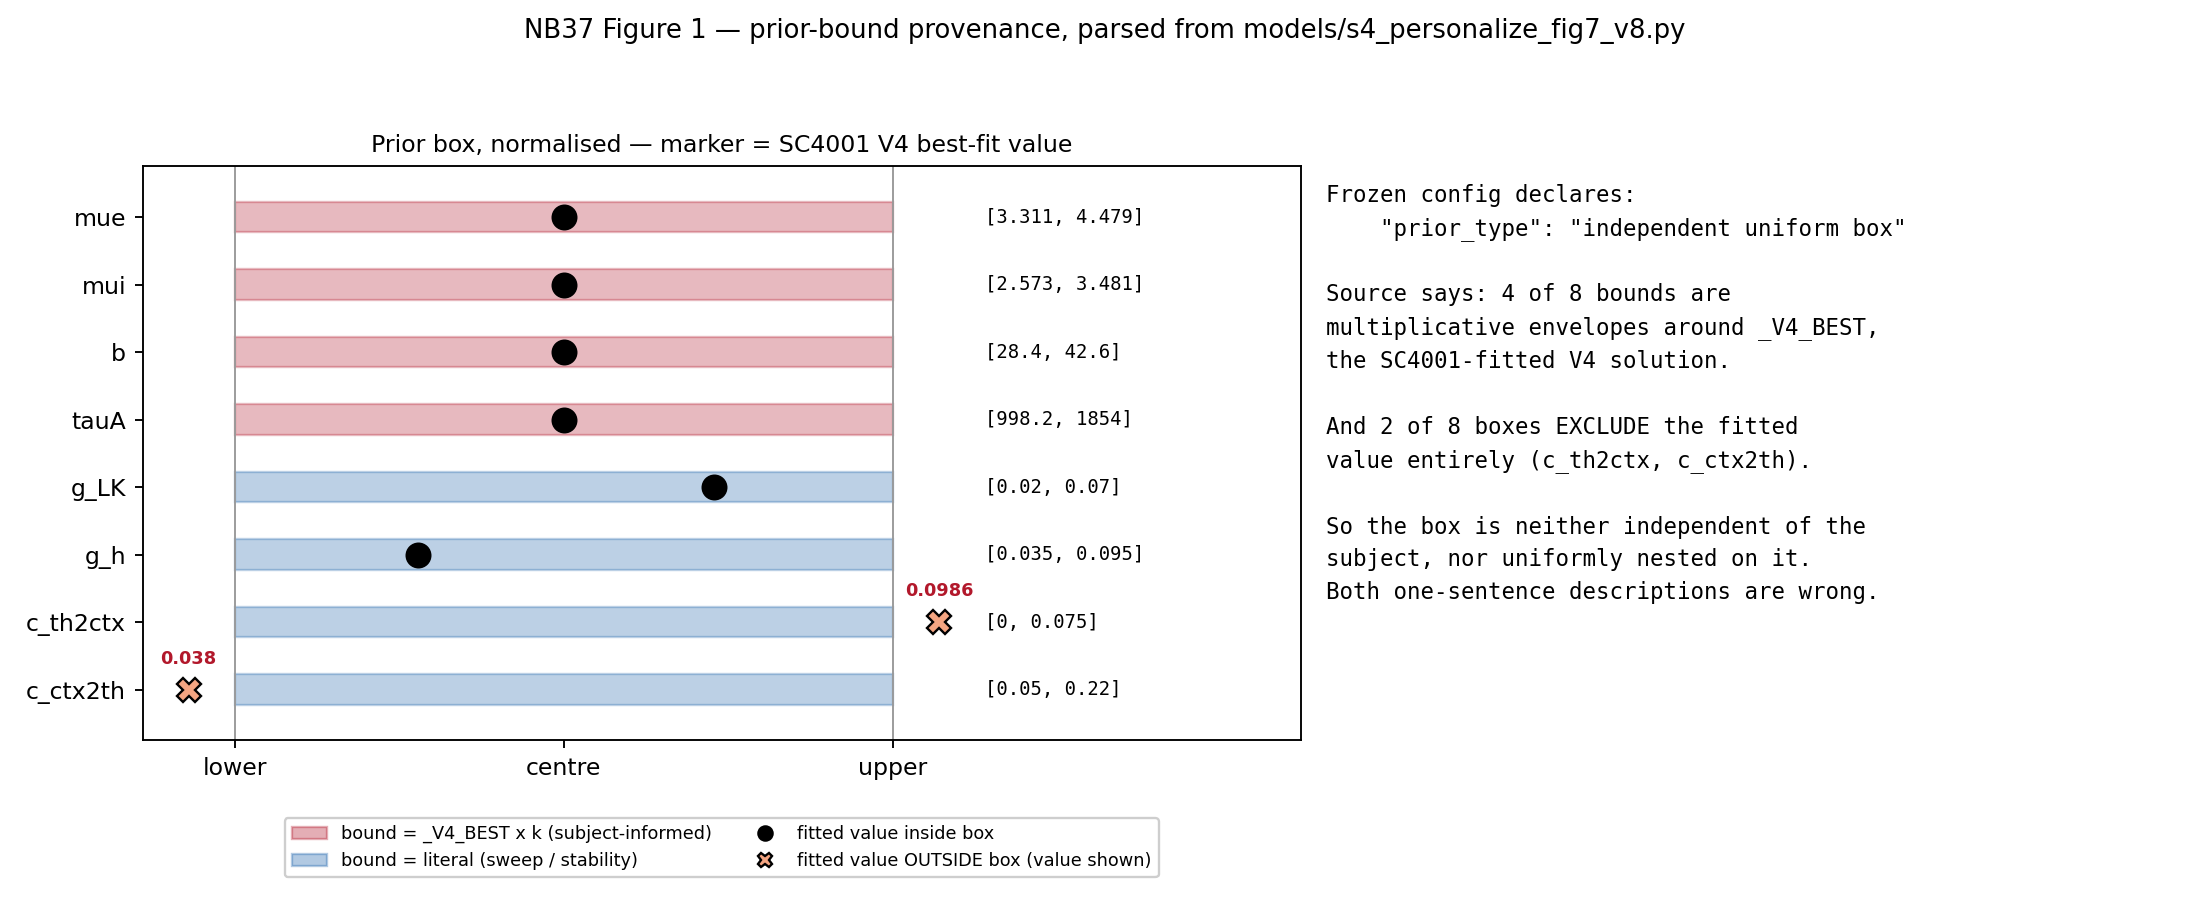

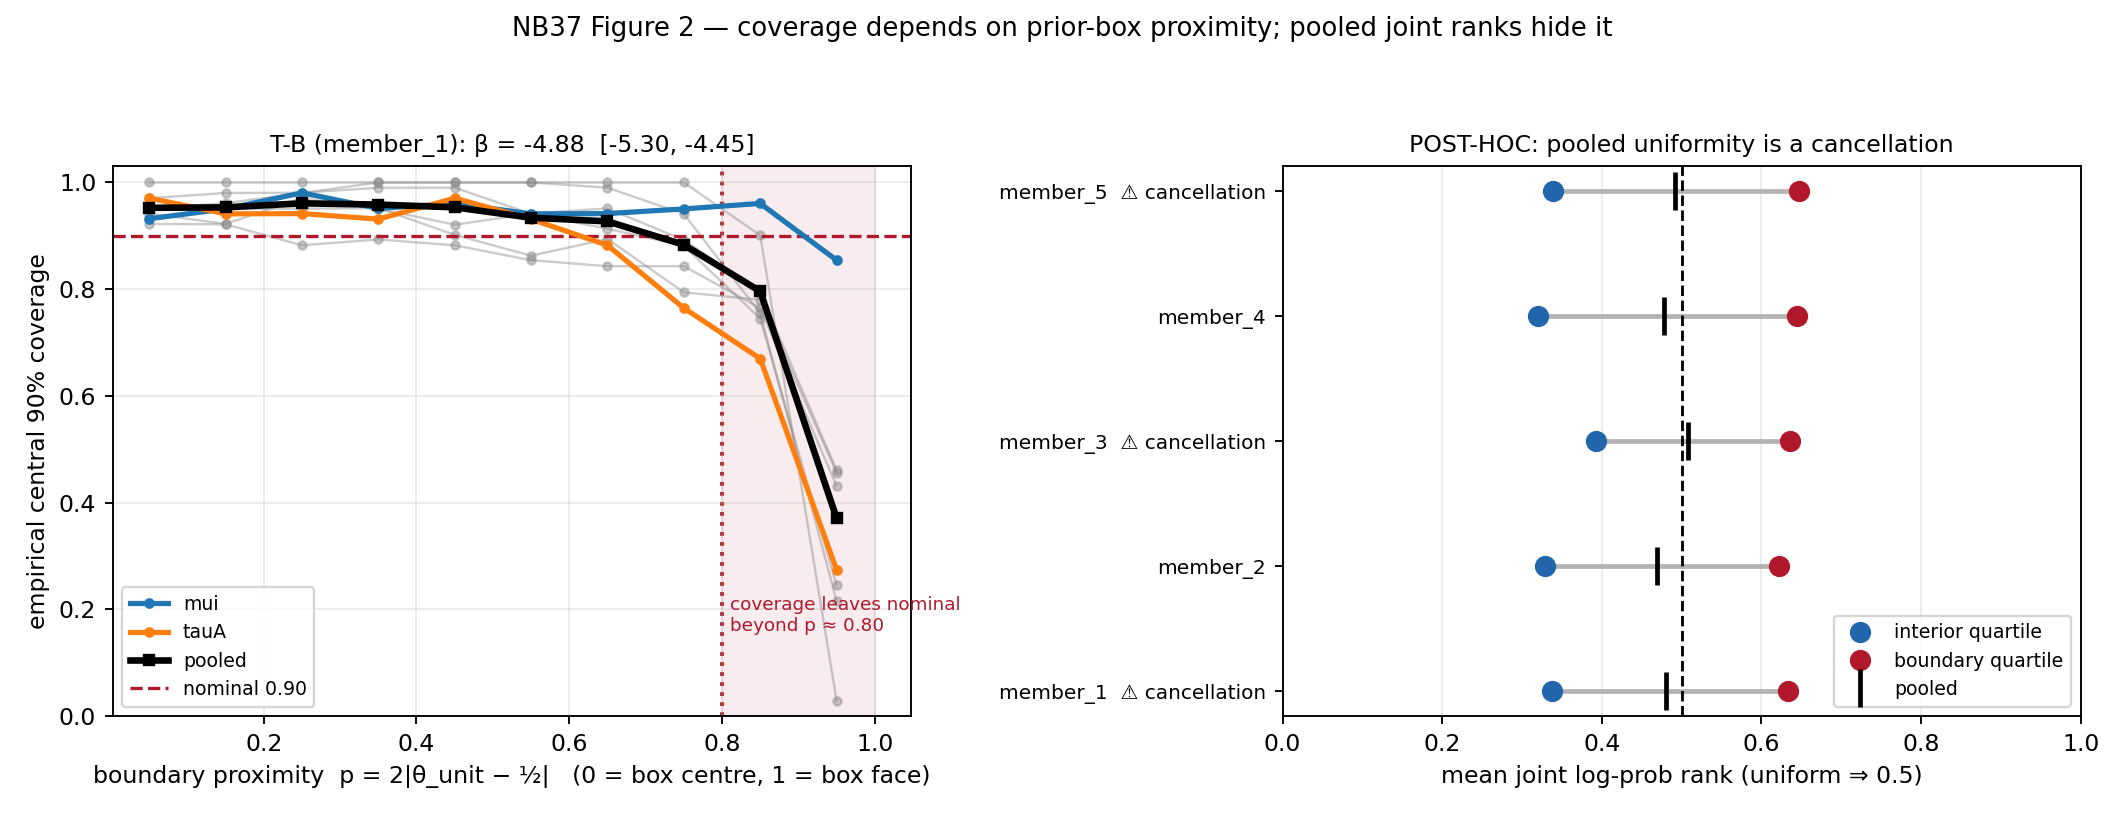

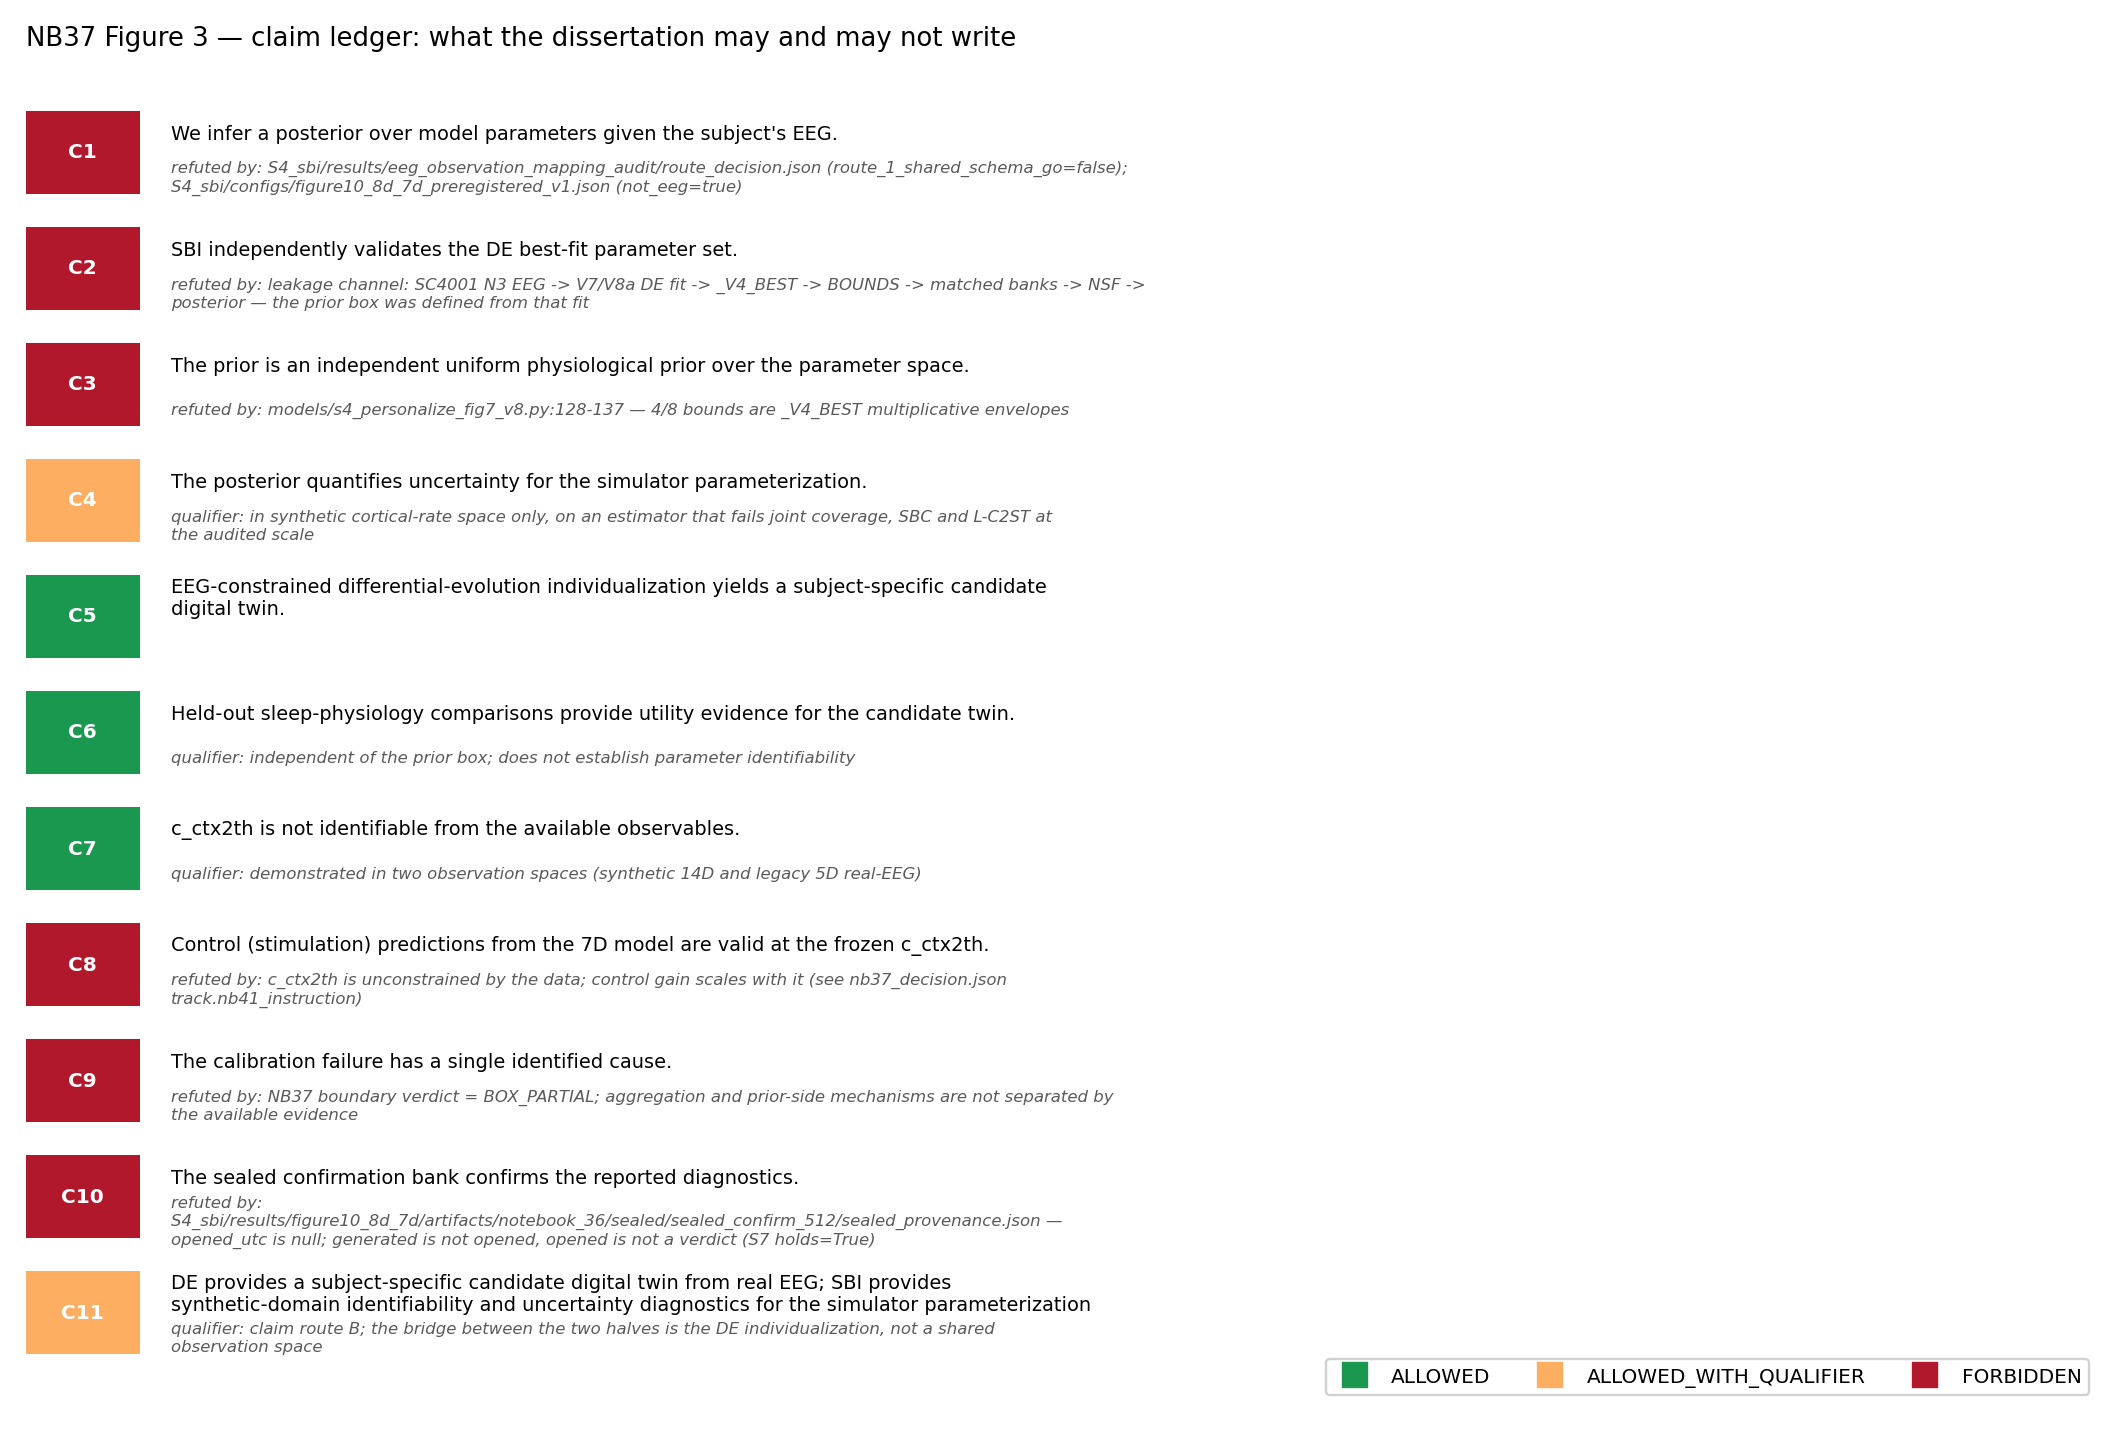

In [23]:
from IPython.display import Image, display
for path in (f1, f2, f3):
    display(Image(filename=str(path)))

In [24]:
summary_path = nb37.write_summary(
    decision, provenance, ledger, structure, member_results, breakpoint_info,
    paths["root"] / "notebook_37_summary.md",
)
print(summary_path.read_text(encoding="utf-8"))

# Notebook 37 (Claude) — summary

- generated: 2026-08-07T03:23:37.381419+00:00
- protocol lock sha256: `acbfa9cbc1ee3a750bca53e086e5607169f99d090fb887119da970c7acce3894`
- decision status: **CONDITIONAL_GO**
- claim route: **B**
- primary track: **7D_PRIMARY_WITH_SCOPED_CONTROL_LIMITATION**
- boundary verdict: **BOX_PARTIAL**

## Q1 — what the prior box actually is

4 of 8 bounds are multiplicative envelopes around `_V4_BEST`, the SC4001-fitted V4 solution, while the frozen config declares the prior an "independent uniform box". Both descriptions cannot hold.

A second finding: 2 of 8 boxes **exclude** the fitted value entirely (`c_th2ctx` 0.0986 vs box [0, 0.075]; `c_ctx2th` 0.038 vs box [0.05, 0.22]). So 'the prior is centred on the subject's fit' is also wrong. The box is *per-parameter heterogeneous*, and only a per-parameter statement is defensible.

## Q2 — is the box implicated in the calibration failure?

**T-B (pre-registered, primary).** Coverage falls sharply as truth appro

## Artifact inventory

In [25]:
rows = []
for path in sorted(paths["root"].rglob("*")):
    if path.is_file():
        rows.append({
            "artifact": path.relative_to(paths["root"]).as_posix(),
            "bytes": path.stat().st_size,
            "sha256": nb37.sha256_file(path)[:16],
        })
inventory = pd.DataFrame(rows)
inventory.to_csv(paths["csv"] / "artifact_inventory.csv", index=False)
print(f"{len(inventory)} artifacts under {paths['root'].relative_to(PROJECT_ROOT)}")
inventory

18 artifacts under S4_sbi\results\figure10_8d_7d\artifacts\notebook_37_claude


,artifact,bytes,sha256
0,csv/artifact_inventory.csv,962,25fd1c4d58df6f16
1,csv/claim_ledger.csv,3271,b5773e6dec11022d
2,csv/coverage_by_boundary_proximity.csv,3700,7154daec2ab56c4b
3,csv/joint_rank_conditional_structure.csv,1442,2bd5d311eee7deb4
4,csv/prior_bound_provenance.csv,2727,7eadc569510e2aa4
5,csv/settled_facts.csv,3018,77348aae8da6f92e
6,csv/test_b_by_estimator.csv,985,bbd0397773d06ed6
7,figures/fig1_prior_bound_provenance.png,164285,cab0f727108a3fef
8,figures/fig2_boundary_mechanism.png,187138,539060348ff0f56f
9,figures/fig3_claim_ledger.png,357898,7fc68b4dd09704c6


---

## What this notebook changed

1. **The prior box is per-parameter heterogeneous.** Four of eight bounds are `_V4_BEST`
   multiplicative envelopes; two of the remaining four *exclude* the fitted value. The frozen
   config's `"independent uniform box"` and the intuitive "nested on the subject's fit" are both
   wrong, in opposite directions.

2. **Coverage collapses toward the prior-box faces**, in every single member and in the ensemble
   (β ≈ −4.9, all CIs excluding zero). Under exact calibration this dependence cannot exist, so it
   is structured miscalibration.

3. **Member-level joint-rank "pass" is a cancellation artefact.** Interior and boundary cases
   deviate from uniformity in opposite directions and cancel in the pooled statistic. A pooled
   joint-rank KS that passes at α = 0.05 is not evidence of joint calibration.

4. **The track question is resolved, not deferred** — `c_ctx2th` is uninformed in two independent
   observation spaces and uncorrelated with the other parameters, so freezing it is safe for
   *recovery* and unsafe only for *control gain*, which becomes one concrete instruction for NB41.

5. **The honest limit is stated**: none of this isolates *subject-nesting* as the cause. In 8D,
   ~90% of uniform-box mass is boundary-adjacent, so this is a hard-box-in-high-dimension pathology
   that no re-anchoring of the same box shape will remove.